# **MÓDULO 14 - Exercício**
# Pré Processamento dos Dados - A primeira etapa Pré Modelagem

Para nossa atividade usaremos uma base de churn também, porém essa base não diz respeito a serviços bancários e sim serviços de internet, telefone e tv - Telecomunicação.

Vamos realizar aqui as etapas de limpeza e tratamento de dados vistos durante a aula, porém aplicados a essa base nova.

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [4]:
#Lembrem-se sempre de alterar a importação dos dados de acordo com o diretório de vocês.
df = pd.read_csv("CHURN_TELECON_MOD08_TAREFA.csv", delimiter=';')

df.head(10)

,customerID,Genero,Idoso,Casado,Dependents,Tempo_como_Cliente,PhoneService,Servico_Internet,Servico_Seguranca,Suporte_Tecnico,StreamingTV,Tipo_Contrato,PaymentMethod,Pagamento_Mensal,Total_Pago,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,DSL,No,No,No,Month-to-month,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,DSL,Yes,No,No,One year,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,DSL,Yes,No,No,Month-to-month,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,DSL,Yes,Yes,No,One year,Bank transfer (automatic),NaN,1840.75,No
4,9237-HQITU,NaN,0,No,No,2,Yes,Fiber optic,No,No,No,Month-to-month,Electronic check,NaN,151.65,Yes
5,9305-CDSKC,NaN,0,No,No,8,Yes,Fiber optic,No,No,Yes,Month-to-month,Electronic check,NaN,820.50,NaN
6,1452-KIOVK,NaN,0,No,Yes,22,Yes,Fiber optic,No,No,Yes,Month-to-month,Credit card (automatic),NaN,1949.40,NaN
7,6713-OKOMC,NaN,0,No,No,10,No,DSL,Yes,No,No,Month-to-month,Mailed check,NaN,301.90,NaN
8,7892-POOKP,NaN,0,Yes,No,28,Yes,Fiber optic,No,Yes,Yes,Month-to-month,Electronic check,NaN,3046.05,NaN
9,6388-TABGU,NaN,0,No,Yes,62,Yes,dsl,Yes,No,No,One year,Bank transfer (automatic),NaN,3487.95,NaN


Legenda dos dados:

*   **CustomerID** : Esse é o ID único de cada cliente nosso da rede de produtos de telecomunicação.

*   **Genero** : O genero dos nossos clientes.

*   **Idoso** : Se nosso cliente tem acima de 60 anos ou não. (Sim = 1 | Não = 0)

*   **Casado** : Se nosso cliente é casado ou não.

*   **Dependents** : Se cliente tem dependentes.

*   **Tempo_como_Cliente** : Tempo em meses que nosso cliente está com a nossa empresa.

*   **PhoneService** : Se ele contratou serviço telefônico com a nossa empresa.

*   **Servico_Internet** : Qual o tipo de serviço de internet contratado.

*   **Servico_Seguranca** : Se ele contratou serviço de segurança com a nossa empresa.

*   **Suporte_Tecnico** : Se já acionou o suporte técnico.

*   **StreamingTV** : Se ele contratou serviço de streaming para TV.

*   **Tipo_Contrato** : Qual o tipo de contrato dos nossos clientes, se era mensal, anual etc.

*   **Tipo_Contrato** : Qual o tipo de contrato dos nossos clientes, se era mensal, anual etc.

*   **PaymentMethod** : Forma de Pagamento.

*   **Pagamento_Mensal** : Quanto o cliente pagava mensalmente.

*   **Total_Pago** : Total já pago pelo cliente para nossa companhia.

*   **Churn** : Nossa coluna mais importante, se nosso cliente nos abandonou ou não.




# 1 - Carregue a base, verifique se os tipos de dados estão de acordo com cada coluna e caso não estejam realize a transformação dos tipos de dados.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customerID          2500 non-null   object 
 1   Genero              2488 non-null   object 
 2   Idoso               2500 non-null   int64  
 3   Casado              2500 non-null   object 
 4   Dependents          2500 non-null   object 
 5   Tempo_como_Cliente  2500 non-null   int64  
 6   PhoneService        1018 non-null   object 
 7   Servico_Internet    2500 non-null   object 
 8   Servico_Seguranca   2500 non-null   object 
 9   Suporte_Tecnico     2500 non-null   object 
 10  StreamingTV         2500 non-null   object 
 11  Tipo_Contrato       2500 non-null   object 
 12  PaymentMethod       2500 non-null   object 
 13  Pagamento_Mensal    2175 non-null   float64
 14  Total_Pago          2500 non-null   float64
 15  Churn               2495 non-null   object 
dtypes: flo

# 2 - Esse exercício faremos por etapas:
A) Verifique se temos colunas com dados faltantes e traga a % dos dados faltantes por coluna.

In [6]:
#seu código aqui
(df.isna().sum() / len(df)) * 100

,0
customerID,0.00
Genero,0.48
Idoso,0.00
Casado,0.00
Dependents,0.00
Tempo_como_Cliente,0.00
PhoneService,59.28
Servico_Internet,0.00
Servico_Seguranca,0.00
Suporte_Tecnico,0.00


B) Exclua nessa etapa as linhas das colunas com dados faltantes que você analisar que esse método é o ideal. Justifique o motivo de estar excluindo essas linhas.

In [7]:
df.dropna(subset=['Genero'], inplace=True)

df['Genero'].isnull().sum()

np.int64(0)

In [8]:
df.dropna(subset=['Churn'], inplace=True)

df['Churn'].isnull().sum()

np.int64(0)

---


As colunas "Genero" e "Churn" contém valores nulos, mas representam menos de 1% do Data Frame. Então são escolhas fáceis para utilizar a função "dropna", pois a falta deles não impactará o resultado final.

O contrário do que podemos ver na coluna "PhoneService", que contem 59% do nosso DF em dados faltantes.


---

In [9]:
(df.isna().sum() / len(df)) * 100

,0
customerID,0.000000
Genero,0.000000
Idoso,0.000000
Casado,0.000000
Dependents,0.000000
Tempo_como_Cliente,0.000000
PhoneService,59.565916
Servico_Internet,0.000000
Servico_Seguranca,0.000000
Suporte_Tecnico,0.000000


C) Nessa etapa substitua pela média, mediana ou moda as linhas das colunas com valores faltantes que você analisou e entendeu que esse era o melhor método. Não se esqueça de justificar sua escolha.

**Dica variáveis numéricas:** Não se esqueça de verificar a distrbuição dos dados, média e mediana.

**Dica variáveis categóricas:** Caso precise substituir uma variável categórica utilize um gráfico de barras para verificar a que mais aparece e utilizar ela na substituição.
Ou você pode optar por excluir a coluna, mas justifique sua escolha.

Caso opte por substituir você pode utilizar a função fillna:
df['SUACOLUNA'].fillna("VALOR QUE SUBSTITUIRA O NULO", inplace=True)
Ela funcionará como a replace.

<Axes: xlabel='PhoneService', ylabel='Count'>

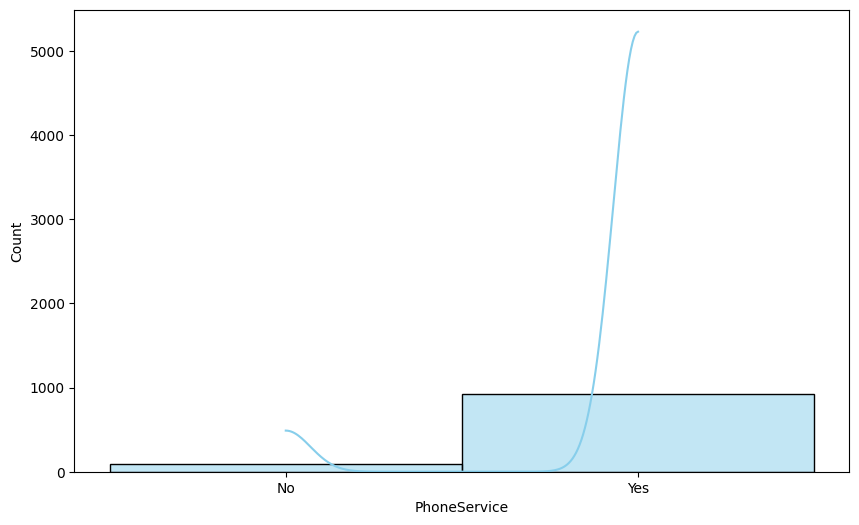

In [10]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='PhoneService', bins=20, kde=True, color='skyblue')

In [11]:
df['PhoneService'].value_counts(normalize=True) * 100

,proportion
PhoneService,
Yes,91.451292
No,8.548708




---

Para a coluna PhoneService, que é a que possui a maior quantidade de dados faltantes, percebemos uma grande discrepância entre a distribuição de seus valores. O Data Frame possui muito mais valores 'Yes', o que significa que poderíamos substituir os valores nulos por 'Yes' sem cause grande impacto.

---



In [12]:
df.fillna({'PhoneService' : 'Yes'}, inplace=True)

df['PhoneService'].isna().sum()

np.int64(0)

<Axes: xlabel='PhoneService', ylabel='Count'>

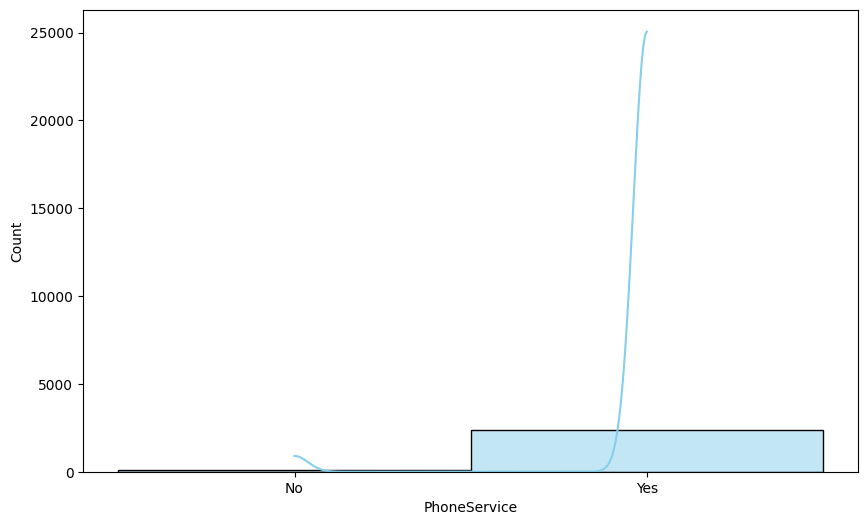

In [13]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='PhoneService', bins=20, kde=True, color='skyblue')

In [14]:
df['PhoneService'].value_counts(normalize=True) * 100

,proportion
PhoneService,
Yes,96.543408
No,3.456592




---

Uma opção válida também seria utilizar "df.drop(columns=['Col_Name'], inplace=True)".
Como substituimos 59% dos valores Nulos por "Yes", tivemos um grande aumento na divergência da distribuição de dados. Se isso foi um problema no futuro, o recomendado será remover a coluna utilizando o método mostrado acima.

---





---



---



In [15]:
(df.isna().sum() / len(df)) * 100

,0
customerID,0.000000
Genero,0.000000
Idoso,0.000000
Casado,0.000000
Dependents,0.000000
Tempo_como_Cliente,0.000000
PhoneService,0.000000
Servico_Internet,0.000000
Servico_Seguranca,0.000000
Suporte_Tecnico,0.000000


In [16]:
df['Pagamento_Mensal'].mean()

np.float64(65.60756321839081)

In [17]:
df['Pagamento_Mensal'].median()

71.45

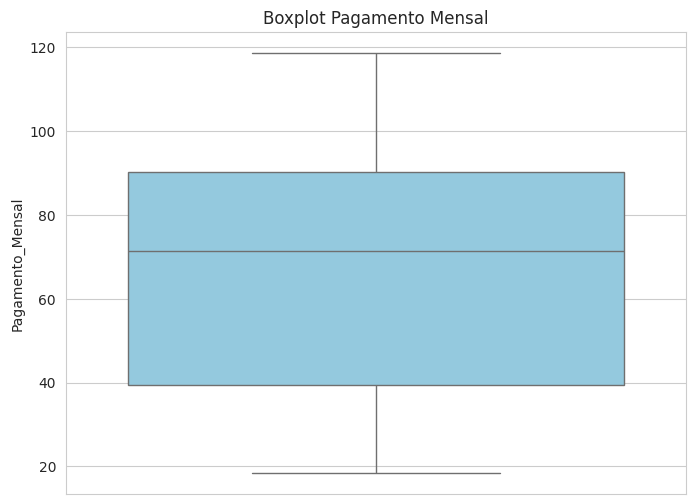

In [18]:
sns.set_style('whitegrid')

plt.figure(figsize=(8, 6))
sns.boxplot(data=df, y='Pagamento_Mensal', color='skyblue')
plt.title('Boxplot Pagamento Mensal')
plt.ylabel('Pagamento_Mensal')
plt.show()

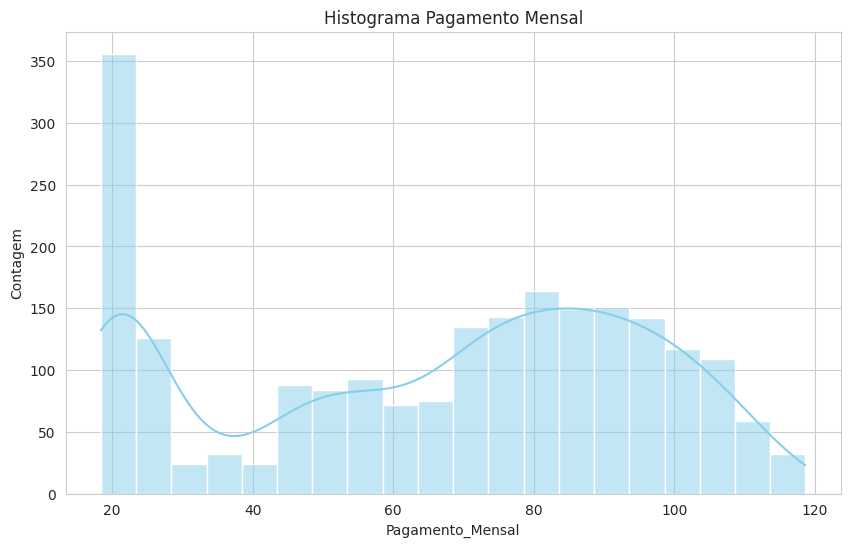

In [19]:
sns.set_style('whitegrid')

plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Pagamento_Mensal', bins=20, kde=True, color='skyblue')
plt.title('Histograma Pagamento Mensal')
plt.xlabel('Pagamento_Mensal')
plt.ylabel('Contagem')
plt.show()

In [20]:
pagamento_maior_20 = df[df['Pagamento_Mensal'] >= 30]

pagamento_maior_20['Pagamento_Mensal'].median()

80.45

In [21]:
pagamento_maior_20['Pagamento_Mensal'].mean()

np.float64(78.51877599524659)



---

Selecionando os valores de Pagamento Mensal maiores ou iguais a 30 conseguimos obter valores melhores de Média e Mediana.
Antes, havia uma diferença de 5.8. Se utilizarmos os Pagamentos maiores ou iguais a 30, a diferença entre Média e Mediana passa a ser apenas de 1.9.

---



In [22]:
media_maior_30 = pagamento_maior_20['Pagamento_Mensal'].mean()

df.fillna({'Pagamento_Mensal' : media_maior_30}, inplace=True)

df['Pagamento_Mensal'].isna().sum()

np.int64(0)

In [23]:
df['Pagamento_Mensal'].mean()

np.float64(67.2318436039036)

In [24]:
df['Pagamento_Mensal'].median()

77.975

# 3 - Verifique se encontramos valores digitados incorretamente, ou com letras maiusculas ou minusculas, ou até mesmo mesmos valores porém escritos de forma dirente e corrija.

In [25]:
df.head(1)

,customerID,Genero,Idoso,Casado,Dependents,Tempo_como_Cliente,PhoneService,Servico_Internet,Servico_Seguranca,Suporte_Tecnico,StreamingTV,Tipo_Contrato,PaymentMethod,Pagamento_Mensal,Total_Pago,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,DSL,No,No,No,Month-to-month,Electronic check,29.85,29.85,No


In [26]:
df['Genero'].unique()

array(['Female', 'Male', 'F', 'M', 'f'], dtype=object)

In [27]:
df['Servico_Internet'].unique()

array(['DSL', 'No', 'Fiber optic', 'dsl'], dtype=object)



---

As duas colunas identificadas com dados escritos de forma errada e distinta.

---



In [28]:
df['Genero'] = df['Genero'].replace('M', 'Male')

df['Genero'] = df['Genero'].replace('F', 'Female')

df['Genero'] = df['Genero'].replace('f', 'Female')


df['Genero'].unique()

array(['Female', 'Male'], dtype=object)

In [29]:
df['Servico_Internet'] = df['Servico_Internet'].str.upper()

df['Servico_Internet'].unique()

array(['DSL', 'NO', 'FIBER OPTIC'], dtype=object)

# [EXTRA] 4 - Caso deseje, para manter um padrão na sua base, renomeie as colunas ou deixando em português, ou inglês.

In [30]:
df.head(1)

,customerID,Genero,Idoso,Casado,Dependents,Tempo_como_Cliente,PhoneService,Servico_Internet,Servico_Seguranca,Suporte_Tecnico,StreamingTV,Tipo_Contrato,PaymentMethod,Pagamento_Mensal,Total_Pago,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,DSL,No,No,No,Month-to-month,Electronic check,29.85,29.85,No


In [31]:
df.rename(columns = {'customerID' : 'ID_Cliente'}, inplace=True)

df.rename(columns = {'Dependents' : 'Dependentes'}, inplace=True)

df.rename(columns = {'PhoneService' : 'Servico_Celular'}, inplace=True)

df.rename(columns = {'PaymentMethod' : 'Metodo_Pagamento'}, inplace=True)


df

,ID_Cliente,Genero,Idoso,Casado,Dependentes,Tempo_como_Cliente,Servico_Celular,Servico_Internet,Servico_Seguranca,Suporte_Tecnico,StreamingTV,Tipo_Contrato,Metodo_Pagamento,Pagamento_Mensal,Total_Pago,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,DSL,No,No,No,Month-to-month,Electronic check,29.850000,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,DSL,Yes,No,No,One year,Mailed check,56.950000,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,DSL,Yes,No,No,Month-to-month,Mailed check,53.850000,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,DSL,Yes,Yes,No,One year,Bank transfer (automatic),78.518776,1840.75,No
16,8191-XWSZG,Female,0,No,No,52,Yes,NO,No internet service,No internet service,No internet service,One year,Mailed check,78.518776,1022.95,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,6188-UXBBR,Female,0,Yes,No,38,Yes,NO,No internet service,No internet service,No internet service,One year,Credit card (automatic),20.250000,814.75,No
2496,2333-KWEWW,Male,0,No,No,18,Yes,NO,No internet service,No internet service,No internet service,Two year,Credit card (automatic),20.050000,388.60,No
2497,5702-SKUOB,Female,0,Yes,No,4,Yes,NO,No internet service,No internet service,No internet service,Month-to-month,Mailed check,19.600000,93.45,No
2498,1134-YWTYF,Male,0,Yes,No,27,Yes,DSL,No,Yes,No,Month-to-month,Electronic check,53.800000,1389.85,No




---



---



In [34]:
df.to_csv('CHURN_TELECON_M15_PRATIQUE.csv', index=False)